# Machine RUL Prediction — NASA C-MAPSS FD001

**Author:** Pallavi

## Exploratory Data Analysis

In the previous notebook, I understood the structure of the FD001 dataset and found that each engine follows its own operating trajectory.

Now I want to explore how the machine measurements behave as the engines move toward failure and identify which features may contain useful information for predicting RUL.

## 1. Preparing the Data for Exploration

To explore the relationship between machine condition and RUL, I first need to load the training data and derive the RUL for each observation from the final cycle of its engine.

In [4]:
# Importing required libraries

import pandas as pd
import numpy as np

In [5]:
# Loading the training data

columns = (
    ["unit_id", "cycle"]
    + [f"setting_{i}" for i in range(1, 4)]
    + [f"sensor_{i}" for i in range(1, 22)]
)

train_df = pd.read_csv(
    "../data/raw/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

# Creating the RUL target

max_cycle = train_df.groupby("unit_id")["cycle"].transform("max")
train_df["RUL"] = max_cycle - train_df["cycle"]

train_df.head()

,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


## 2. Understanding RUL

Before exploring the sensors, I want to understand the target variable itself and how the engine lifetimes are distributed.

In [11]:
# Reviewing RUL and engine lifetime

print("RUL statistics:")
print(train_df["RUL"].describe())

print("\nEngine lifetime statistics:")
print(train_df.groupby("unit_id")["cycle"].max().describe())

RUL statistics:
count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64

Engine lifetime statistics:
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


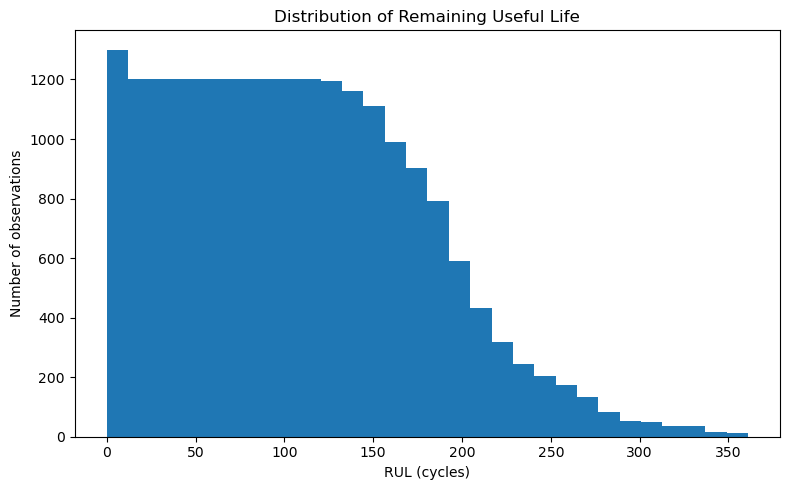

In [12]:
# Plotting and saving the RUL distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
train_df["RUL"].plot(
    kind="hist",
    bins=30
)
plt.title("Distribution of Remaining Useful Life")
plt.xlabel("RUL (cycles)")
plt.ylabel("Number of observations")
plt.tight_layout()
plt.savefig(
    "../reports/figures/rul_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 3. Understanding Sensor Variability

Not every sensor provides useful information for prediction. I will first check how much each sensor varies across the training data before investigating its relationship with RUL.

In [14]:
# Checking sensor variability
sensor_columns = [col for col in train_df.columns if col.startswith("sensor_")]
sensor_std = train_df[sensor_columns].std().sort_values()
sensor_std
# Finding constant sensors
constant_sensors = sensor_std[sensor_std == 0]
constant_sensors

sensor_19    0.0
sensor_18    0.0
dtype: float64

## 4. Exploring Sensor Relationships With RUL
I will examine the correlation between sensor measurements and RUL to identify which sensors may contain useful information for prediction.

In [15]:
# Checking sensor correlations with RUL
correlation = train_df[sensor_columns + ["RUL"]].corr()["RUL"].drop("RUL")
correlation.abs().sort_values(ascending=False)

sensor_11    0.696228
sensor_4     0.678948
sensor_12    0.671983
sensor_7     0.657223
sensor_15    0.642667
sensor_21    0.635662
sensor_20    0.629428
sensor_2     0.606484
sensor_17    0.606154
sensor_3     0.584520
sensor_8     0.563968
sensor_13    0.562569
sensor_9     0.390102
sensor_14    0.306769
sensor_6     0.128348
sensor_1          NaN
sensor_5          NaN
sensor_10         NaN
sensor_16         NaN
sensor_18         NaN
sensor_19         NaN
Name: RUL, dtype: float64

## 5. Visualizing Sensor Relationships

The correlation analysis identified several sensors with stronger relationships with RUL. I will visualize these relationships to make the comparison easier and identify the sensors that may provide useful predictive information.

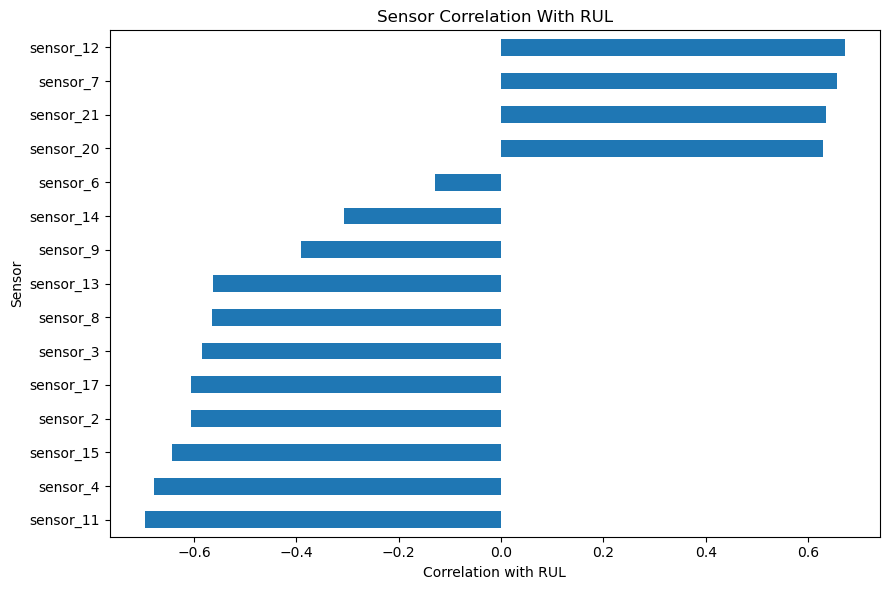

In [16]:
# Plotting sensor correlations with RUL

correlation = correlation.dropna().sort_values()

plt.figure(figsize=(9, 6))

correlation.plot(kind="barh")

plt.title("Sensor Correlation With RUL")
plt.xlabel("Correlation with RUL")
plt.ylabel("Sensor")
plt.tight_layout()

plt.savefig(
    "../reports/figures/sensor_rul_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6. Investigating the Strongest Sensors

Correlation tells us the strength of a linear relationship, but it does not show the actual pattern. I will visualize the strongest sensors against RUL to check whether the relationships are meaningful.

In [17]:
# Selecting the strongest sensors
top_sensors = correlation.abs().sort_values(ascending=False).head(5).index
top_sensors

Index(['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_15'], dtype='object')

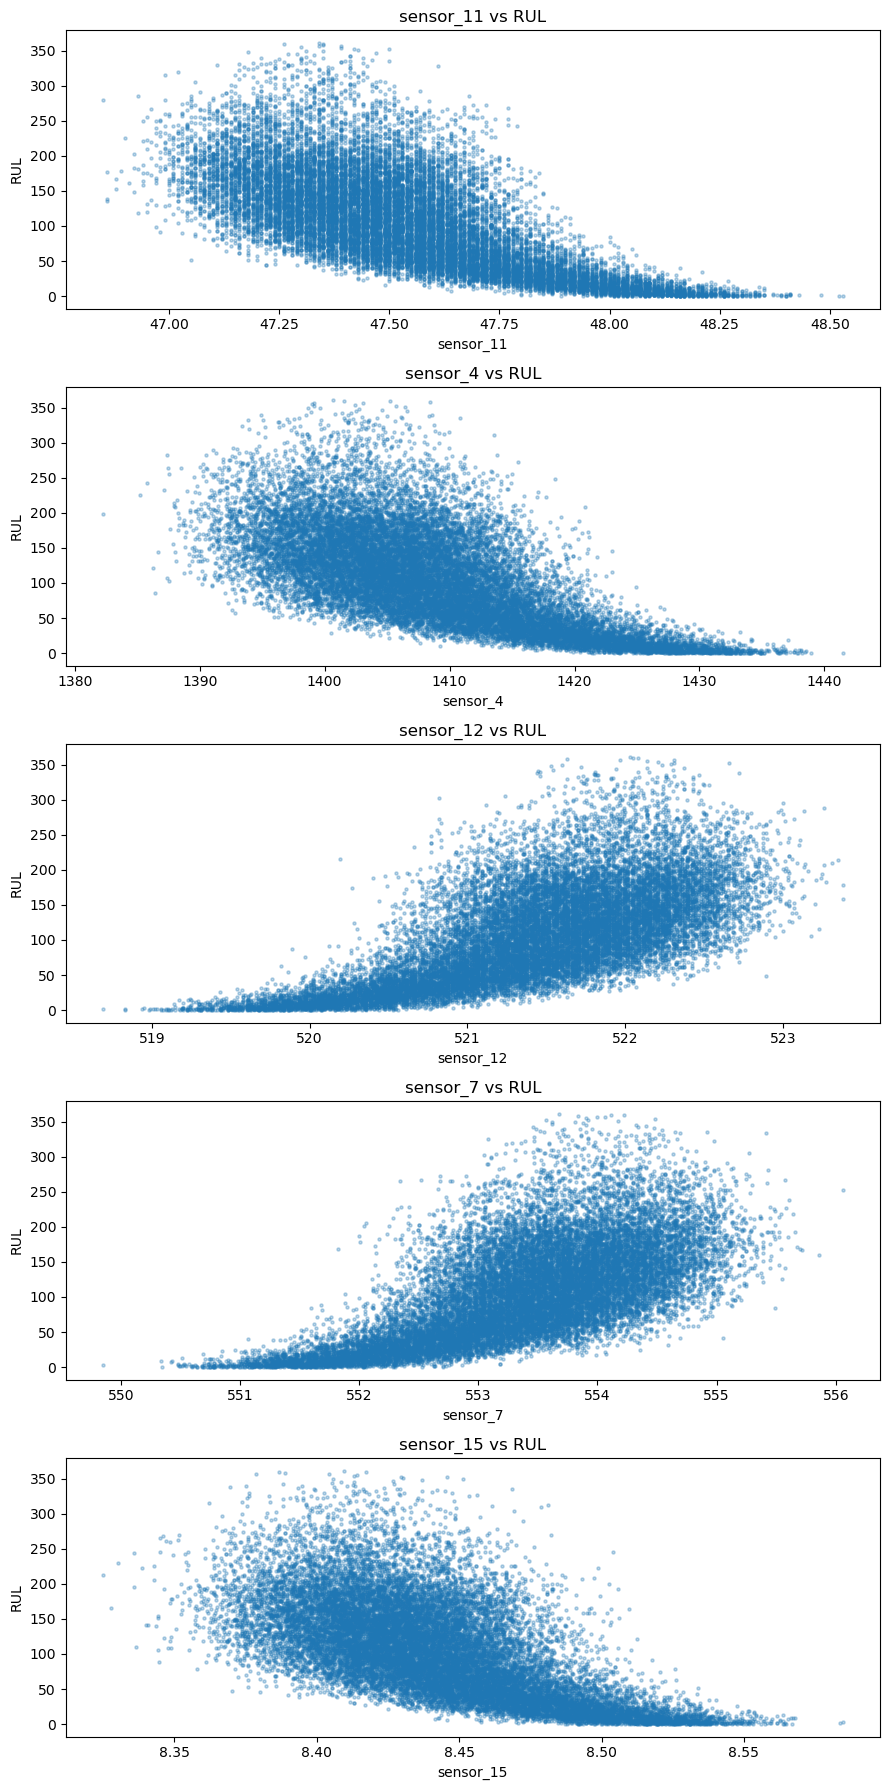

In [18]:
# Plotting the strongest sensor relationships
fig, axes = plt.subplots(5, 1, figsize=(9, 18))
for ax, sensor in zip(axes, top_sensors):
    ax.scatter(train_df[sensor], train_df["RUL"], s=5, alpha=0.3)
    ax.set_title(f"{sensor} vs RUL")
    ax.set_xlabel(sensor)
    ax.set_ylabel("RUL")
plt.tight_layout()
plt.savefig(
    "../reports/figures/top_sensors_vs_rul.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 7. What I Learned From the EDA

The RUL distribution shows that the training data contains observations from different stages of engine life, from healthy operation to conditions close to failure.
The engines also have different operating lifetimes, confirming that each engine follows its own degradation trajectory.

The sensor analysis showed that several measurements have meaningful relationships with RUL. Among the varying sensors, `sensor_11`, `sensor_4`, `sensor_12`, `sensor_7`, and `sensor_15` showed the strongest linear relationships with RUL.

Six sensor columns were constant across the training data and therefore did not provide variation for correlation analysis. One operating-setting column was also constant.

The correlation results give us useful candidates for further investigation, but I will not treat correlation alone as final feature selection. The next step is to prepare the data carefully and decide which features should be used for model training.

### Key EDA takeaway

The dataset contains useful sensor signals for predicting RUL, but some features provide little or no information. This gives us a clear direction for preprocessing and feature selection.